# Predicting Hospital Readmission in Diabetic Patients
## Notebook 6 of 7 - Principal Component Analysis (PCA)

In this notebook I applied **Principal Component Analysis (PCA)** - the only unsupervised method in this project - to the 98-dimensional post-encoding feature space. I used it to answer two questions:

1. **Dimensionality:** How many components were actually needed to represent most of the variance? Could the feature space be meaningfully compressed?
2. **Separability:** Did the three readmission classes occupy geometrically distinct regions, or did they overlap? The answer to this directly explained the prediction ceiling I observed in the supervised models.

It's worth distinguishing PCA from LASSO here. LASSO kept the original features and removed uninformative ones. PCA combined all of them into entirely new axes (principal components) ranked by how much variance each one captured. Crucially, PCA had no knowledge of class labels - it was purely unsupervised and looked at how patients varied from each other regardless of their readmission outcome.

**Figures I produced:**
- Figure 5: Scree Plot (cumulative proportion of variance)
- Figure 6: 2D Scatter Plot (5,000-patient subsample, colored by readmission class)

## A Note on Ordering and Learning

In a conventional ML pipeline, PCA would typically appear *before* the supervised models. If used as a preprocessing step - projecting the data into a lower-dimensional space before training - it would make sense to run it first so the models receive the compressed representation as input.

I placed it after the models because that was not how I used it. Rather than feeding PCA-transformed features into Logistic Regression, Random Forest, or SVM, I applied PCA as a **diagnostic tool** after the fact - to understand why all three models hit a similar accuracy ceiling regardless of algorithm, feature set, or hyperparameter configuration. In that framing, presenting it after the supervised results felt more honest: here are the results, and here is what PCA revealed about why they looked the way they did.

I also want to be transparent that this was my **first time working with PCA**. I had covered it conceptually in lecture but had not applied it to a real dataset before this project. Most of what I learned about how to implement it, interpret the scree plot, and read the loadings came from working through it directly here - consulting the scikit-learn documentation, revisiting my lecture notes, and iterating on the plots until the output matched what I understood the method to be doing. The comments throughout the code reflect that process of learning as I went.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

## 2. Load Data

In [2]:
X_train_scaled = np.load('X_train_scaled.npy')
X_test_scaled  = np.load('X_test_scaled.npy')
y_train        = np.load('y_train.npy')
y_test         = np.load('y_test.npy')

feature_names = (
    pd.read_excel('diabetic_data_cleaned.xlsx')
      .drop(columns=['encounter_id', 'patient_nbr', 'readmitted'])
      .columns
)

print(f"Training set: {X_train_scaled.shape}")

Training set: (71236, 98)


## 3. Figure 5: Scree Plot - Cumulative Proportion of Variance

I fit PCA with all 98 components and computed how much **cumulative variance** each additional component explained. I used `np.cumsum()` on the per-component variance ratios to get the running total, then identified the first index where that total crossed 80%, 90%, and 95%.

Proportion of Variance Thresholds
  80% variance explained by 56 components
  90% variance explained by 67 components
  95% variance explained by 73 components
  PC1 alone explains: 3.43%
  PC2 alone explains: 2.64%
  PC1+PC2 combined:   6.07%


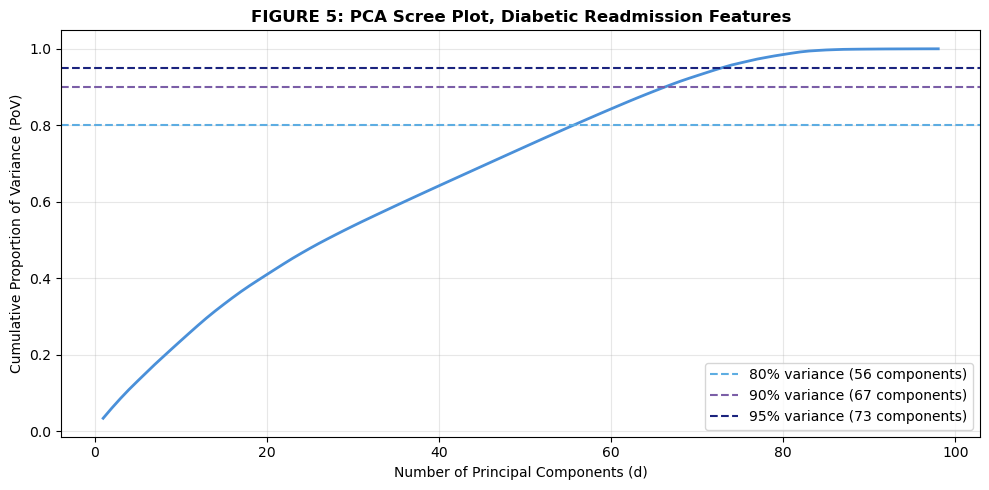

Saved to pca_scree_plot.png


In [3]:
def plot_scree():
    pca_full = PCA(n_components=None, random_state=42)  # n_components=None fits all 98 components
    pca_full.fit(X_train_scaled)

    cumulative_var = np.cumsum(pca_full.explained_variance_ratio_)

    # argmax finds the first index where cumulative variance crosses each threshold
    # I added 1 to convert from zero-based index to actual component count
    n_80 = np.argmax(cumulative_var >= 0.80) + 1
    n_90 = np.argmax(cumulative_var >= 0.90) + 1
    n_95 = np.argmax(cumulative_var >= 0.95) + 1

    print("Proportion of Variance Thresholds")
    print(f"  80% variance explained by {n_80} components")
    print(f"  90% variance explained by {n_90} components")
    print(f"  95% variance explained by {n_95} components")
    print(f"  PC1 alone explains: {pca_full.explained_variance_ratio_[0]*100:.2f}%")
    print(f"  PC2 alone explains: {pca_full.explained_variance_ratio_[1]*100:.2f}%")
    print(f"  PC1+PC2 combined:   {cumulative_var[1]*100:.2f}%")

    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(cumulative_var) + 1), cumulative_var,
             color='#4A90D9', linewidth=2)
    plt.axhline(y=0.80, color='#5DADE2', linestyle='--',
                label=f'80% variance ({n_80} components)')
    plt.axhline(y=0.90, color='#7B5EA7', linestyle='--',
                label=f'90% variance ({n_90} components)')
    plt.axhline(y=0.95, color='#1A237E', linestyle='--',
                label=f'95% variance ({n_95} components)')
    plt.xlabel('Number of Principal Components (d)')
    plt.ylabel('Cumulative Proportion of Variance (PoV)')
    plt.title('FIGURE 5: PCA Scree Plot, Diabetic Readmission Features',
              fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('pca_scree_plot.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved to pca_scree_plot.png")

    return pca_full  # returned the fitted object so I could use it in print_top_contributors

pca_full = plot_scree()

## 4. Figure 6: 2D Projection - Patient Groupings by Readmission Class

I projected all patients down to 2 dimensions and colored them by readmission class to see whether the classes occupied distinct regions or overlapped. I used a **5,000-patient subsample** from the 71k training set to avoid overplotting - the PCA components themselves were computed on the full training set.

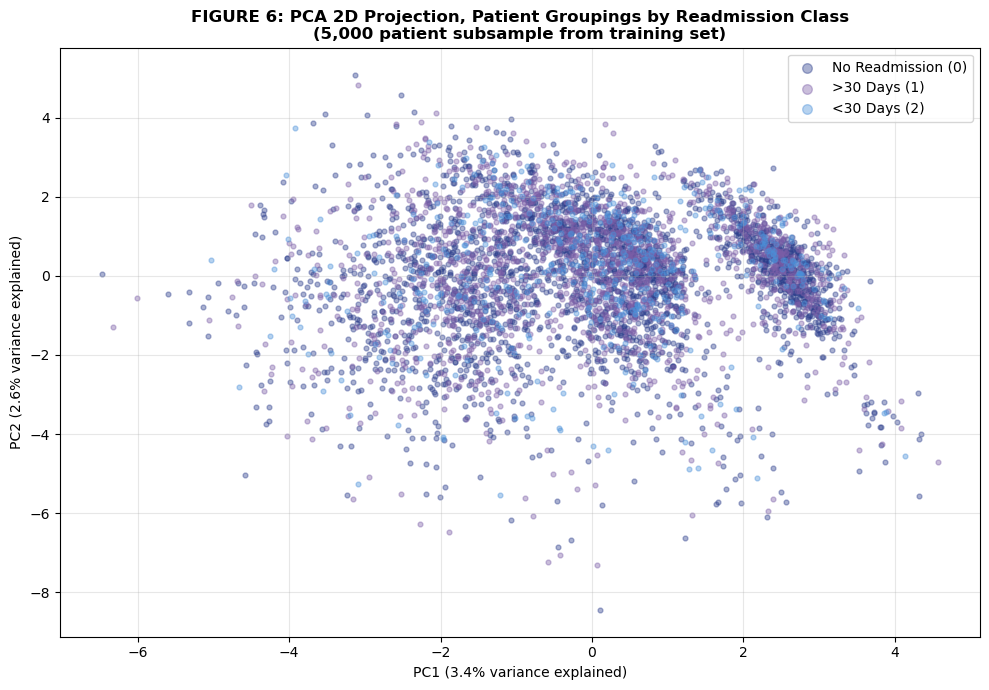

Saved to pca_2d_scatterplot.png


In [4]:
def plot_2d_projection():
    pca_2d = PCA(n_components=2, random_state=42)
    X_2d = pca_2d.fit_transform(X_train_scaled)  # fit_transform learned the components and projected in one step

    var_pc1 = pca_2d.explained_variance_ratio_[0] * 100
    var_pc2 = pca_2d.explained_variance_ratio_[1] * 100

    np.random.seed(42)
    idx = np.random.choice(len(X_2d), size=5000, replace=False)

    colors = {0: '#2C3E8C', 1: '#7B5EA7', 2: '#4A90D9'}
    labels = {0: 'No Readmission (0)', 1: '>30 Days (1)', 2: '<30 Days (2)'}

    plt.figure(figsize=(10, 7))
    for cls in [0, 1, 2]:
        mask = y_train[idx] == cls
        plt.scatter(X_2d[idx][mask, 0], X_2d[idx][mask, 1],
                    c=colors[cls], label=labels[cls],
                    alpha=0.4, s=12)  # alpha made points semi-transparent so overlapping areas were visible

    plt.xlabel(f'PC1 ({var_pc1:.1f}% variance explained)')
    plt.ylabel(f'PC2 ({var_pc2:.1f}% variance explained)')
    plt.title(
        'FIGURE 6: PCA 2D Projection, Patient Groupings by Readmission Class\n'
        '(5,000 patient subsample from training set)',
        fontweight='bold'
    )
    plt.legend(markerscale=2)  # markerscale=2 made the legend dots larger and easier to see
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('pca_2d_scatterplot.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved to pca_2d_scatterplot.png")

plot_2d_projection()

## 5. Top Feature Contributions to PC1 and PC2

I examined the loadings (eigenvector coefficients) for each component to understand which original features were driving them. A positive loading pushed patients in the positive PC direction; a negative loading pushed them the other way.

In [5]:
def print_top_contributors(pca_full, top_n=10):
    print(f"Top {top_n} Feature Contributions to PC1 and PC2")
    for pc_idx in [0, 1]:
        loadings = pca_full.components_[pc_idx]  # row of eigenvector coefficients for this component
        top_idx  = np.argsort(np.abs(loadings))[::-1][:top_n]  # sorted by absolute value descending
        print(f"\nPC{pc_idx+1} (explains {pca_full.explained_variance_ratio_[pc_idx]*100:.2f}% variance):")
        for i in top_idx:
            print(f"  {feature_names[i]}: {loadings[i]:.4f}")

print_top_contributors(pca_full, top_n=10)

Top 10 Feature Contributions to PC1 and PC2

PC1 (explains 3.43% variance):
  change_No: 0.4215
  diabetesMed_Yes: -0.4023
  insulin_No: 0.2848
  metformin_No: 0.2709
  metformin_Steady: -0.2507
  num_medications: -0.2351
  rosiglitazone_No: 0.1630
  pioglitazone_No: 0.1618
  rosiglitazone_Steady: -0.1581
  pioglitazone_Steady: -0.1554

PC2 (explains 2.64% variance):
  num_lab_procedures: 0.2980
  max_glu_serum_Not tested: 0.2876
  metformin_No: 0.2838
  metformin_Steady: -0.2797
  number_diagnoses: 0.2575
  max_glu_serum_Norm: -0.2478
  time_in_hospital: 0.2362
  admission_type_id: -0.2164
  glyburide_No: 0.2022
  glyburide_Steady: -0.2000


## 6. Interpretation

**Scree plot:** 80% of total variance required **56 components** - meaning the information in this dataset was genuinely spread across almost the entire feature space with no small group of dominant underlying patterns driving most of the variation.

**2D scatter:** The three readmission classes overlapped almost completely across the entire plot. There was no part of the space where one class pulled away cleanly from the others. This was the most important takeaway from my entire analysis. The three groups of patients did not look meaningfully different from each other in this feature space, at least not along the directions that carried the most information. This finding explained why every supervised model hit a similar ceiling and why Class 2 was so consistently difficult to identify - it wasn't a modeling problem, it was a data structure problem.

**PC1 loadings** were dominated by medication management features (whether drugs were changed, whether insulin or metformin was prescribed) - essentially separating patients who were being actively managed for diabetes from those who were not. **PC2 loadings** reflected clinical complexity (`num_lab_procedures`, `number_diagnoses`, `time_in_hospital`, glucose serum results), which closely mirrored what Random Forest had identified as the most predictive features.